<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Prediction%20of%20Wine%20type%20using%20Deep%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

In [2]:
red = pd.read_csv("redwinequality.csv",sep=';')
white = pd.read_csv("whitewinequality.csv",sep=';')

red['type'] = 1
white['type'] = 0

wines = pd.concat([red,white],ignore_index=True)
wines.dropna(inplace=True)

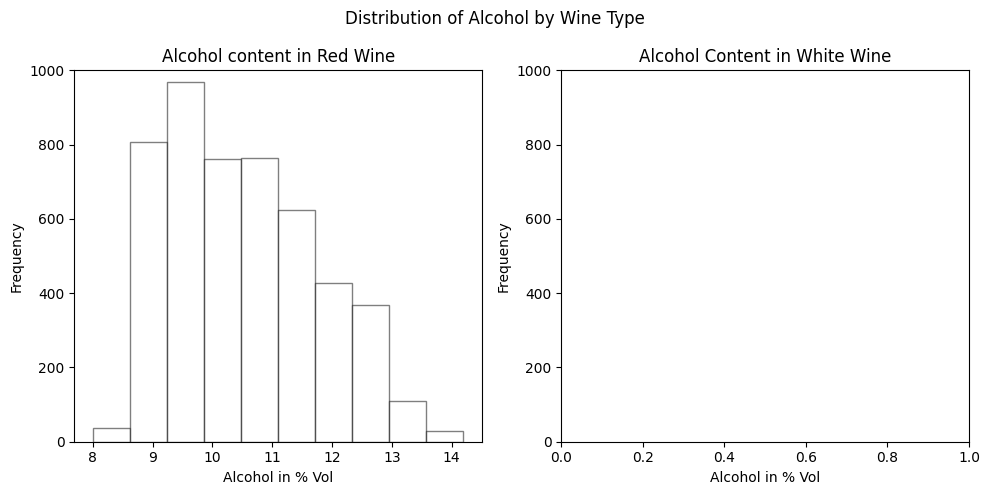

In [3]:
#Plot the distribution of Alcohol
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].hist(wines[wines['type'] ==0].alcohol,bins=10,facecolor='white',edgecolor='black',lw=0.5,alpha=0.5,label='Whitewine')

for a in ax:
  a.set_ylim([0,1000])
  a.set_xlabel('Alcohol in % Vol')
  a.set_ylabel('Frequency')

ax[0].set_title('Alcohol content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

In [4]:
#Splitthje data into traing and testing set
X =wines.iloc[:,:-1]
y = wines['type']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.34,random_state=45)

In [6]:
#Creating a neural network
model = Sequential()
model.add(Dense(12,activation='relu',input_dim=12))
model.add(Dense(9,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#Training the model
model.fit(X_train,y_train,epochs=3,batch_size=1,verbose=1)

Epoch 1/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9088 - loss: 0.3834
Epoch 2/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9366 - loss: 0.1794
Epoch 3/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9515 - loss: 0.1511


In [8]:
#Making Predictions
y_pred = model.predict(X_test)

y_pred_labels = (y_pred >=0.5).astype(int)

for prediction in y_pred_labels[:12]:
  wine_type = "Red wine" if prediction == 1 else "White wine"
  print(f"Prediction:{wine_type}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Prediction:White wine
Prediction:White wine
Prediction:White wine
Prediction:White wine
Prediction:White wine
Prediction:Red wine
Prediction:Red wine
Prediction:White wine
Prediction:Red wine
Prediction:White wine
Prediction:White wine
Prediction:White wine
